In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/ML UTS"

'train_transaction (1).csv'


In [ ]:
!pip install optuna mlflow -q

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score,f1_score,classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

import optuna
import mlflow

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/ML UTS/train_transaction (1).csv"
)
print(df.shape)
df.head()

(590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
missing = df.isnull().mean()*100

missing.sort_values(ascending=False).head(20)

,0
dist2,93.628374
D7,93.409930
D13,89.509263
D14,89.469469
D12,89.041047
D6,87.606767
D8,87.312290
D9,87.312290
V162,86.123717
V142,86.123717


In [ ]:
threshold = 80

drop_cols = missing[missing > threshold].index

df.drop(columns=drop_cols,inplace=True)

print(df.shape)

(590540, 339)


In [ ]:
df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [ ]:
missing_percent = df.isnull().mean() * 100

keep_cols = missing_percent[missing_percent <= 80].index

df = df[keep_cols]

In [ ]:
print(df.shape)

(590540, 339)


In [ ]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,569877
1,20663


In [ ]:
df['isFraud'].value_counts(normalize=True) * 100


,proportion
isFraud,
0,96.500999
1,3.499001


In [ ]:
missing = df.isnull().mean() * 100

missing.sort_values(ascending=False).head(20)

,0
V263,77.913435
V264,77.913435
V265,77.913435
V266,77.913435
V267,77.913435
V268,77.913435
V269,77.913435
V258,77.913435
V257,77.913435
V262,77.913435


In [ ]:
threshold = 80

keep_cols = missing[missing <= threshold].index

df = df[keep_cols]

print(df.shape)

(590540, 339)


In [ ]:
y = df['isFraud']

X = df.drop('isFraud', axis=1)

In [ ]:
cat_cols = X.select_dtypes(include='object').columns

print(cat_cols)
print(len(cat_cols))

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'],
      dtype='object')
14


In [ ]:
num_cols = X.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

In [ ]:
for col in cat_cols:
    X[col] = X[col].fillna('Unknown')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,569877
1,20663


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5181288961224123), np.int64(1): np.float64(14.290139140955837)}


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        43,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=4096,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc: 0.5007 - loss: 3.1583 - val_auc: 0.5000 - val_loss: 0.6968
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.4973 - loss: 2.1876 - val_auc: 0.5000 - val_loss: 0.6964
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.5001 - loss: 3.3504 - val_auc: 0.5000 - val_loss: 0.6972
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.4986 - loss: 1.7085 - val_auc: 0.5000 - val_loss: 0.6972
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.4984 - loss: 1.0664 - val_auc: 0.5000 - val_loss: 0.6970
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.4989 - loss: 1.4205 - val_auc: 0.5000 - val_loss: 0.6958
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.4998 - loss: 1.9169 - val_auc: 0.5000 - val_loss: 0.6959
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.5000 - loss: 0.9375 - val_auc: 0.5000 - val_loss: 0.6960
Epoch 9/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.4960 - lo

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict(X_test)

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
ROC-AUC: 0.5


In [ ]:
from sklearn.metrics import f1_score

y_pred = (y_prob > 0.5).astype(int)

print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.06762052012009064


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00    113975
           1       0.03      1.00      0.07      4133

    accuracy                           0.03    118108
   macro avg       0.02      0.50      0.03    118108
weighted avg       0.00      0.03      0.00    118108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[     0 113975]
 [     0   4133]]


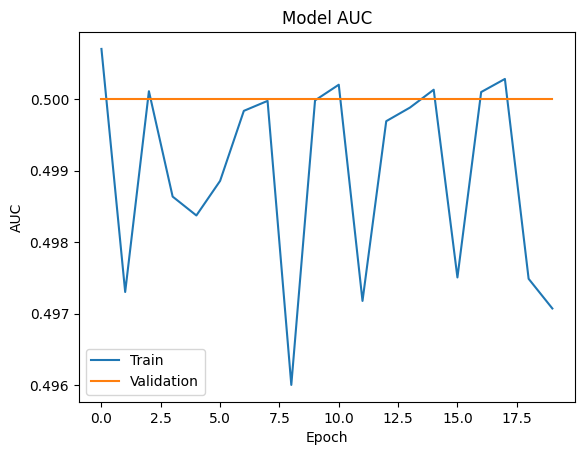

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])

plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score

def objective(trial):

    n1 = trial.suggest_int("n1", 64, 256)
    n2 = trial.suggest_int("n2", 32, 128)

    dropout = trial.suggest_float(
        "dropout",
        0.1,
        0.5
    )

    lr = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout),

        Dense(n2, activation='relu'),
        Dropout(dropout),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['AUC']
    )

    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=4096,
        verbose=0,
        class_weight=class_weights
    )

    y_prob = model.predict(
        X_test,
        verbose=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    return auc